In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

#ruta_base = "/content/drive/MyDrive/GHI/data_raw/GEIH_2023"
#ruta_base ="/content/drive/MyDrive/Proyecto IntroML/GHI/data_raw/GEIH_2023" # ubicación drive sebas
ruta_base ="/content/drive/MyDrive/MIAD/IML/data_raw/GEIH_2023" # ubicación drive Javier
meses = os.listdir(ruta_base)

In [ ]:
lista_ft = []

for mes in meses:
    ruta = os.path.join(ruta_base, mes, "Fuerza_Trabajo.CSV")
    df = pd.read_csv(ruta, encoding="latin1", sep=";", low_memory=False)
    df["MES"] = mes
    lista_ft.append(df)

fuerza_trabajo = pd.concat(lista_ft, ignore_index=True)

lista_oc = []

for mes in meses:
    ruta = os.path.join(ruta_base, mes, "Ocupados.CSV")
    df = pd.read_csv(ruta, encoding="latin1", sep=";", low_memory=False)
    df["MES"] = mes
    lista_oc.append(df)

ocupados = pd.concat(lista_oc, ignore_index=True)

lista_cg = []

for mes in meses:
    ruta = os.path.join(ruta_base, mes, "Características_Generales.CSV")
    df = pd.read_csv(ruta, encoding="latin1", sep=";", low_memory=False)
    df["MES"] = mes
    lista_cg.append(df)

caracteristicas = pd.concat(lista_cg, ignore_index=True)

base = fuerza_trabajo.merge(
    caracteristicas,
    on=["DIRECTORIO","SECUENCIA_P","ORDEN","MES"],
    how="left"
)

base = base.merge(
    ocupados,
    on=["DIRECTORIO","SECUENCIA_P","ORDEN","MES"],
    how="left"
)

base_ocupados = base[base["CLASE"] == 1]

base_ocupados.to_parquet(
    #"/content/drive/MyDrive/GHI/data_processed/base_informalidad_2023.parquet"
    #"/content/drive/MyDrive/Proyecto IntroML/GHI/data_processed/base_informalidad_2023.parquet" # ruta drive sebas
    "/content/drive/MyDrive/MIAD/IML/data_processed/base_informalidad_2023.parquet" # Ruta Drive Javier

)

base["CLASE"].value_counts()

base_ocupados = base[base["CLASE"] == 1].copy()
base_ocupados.shape

(320889, 309)

In [ ]:
# Crear variable tamaño empresa (por claridad)
base_ocupados["tam_empresa"] = base_ocupados["P1800S1"]

# Inicializar variable informal
base_ocupados["informal"] = 0

# Definir condiciones
cond1 = base_ocupados["P6430"] == 4  # Cuenta propia
cond2 = base_ocupados["P6430"] == 3  # Doméstico
cond3 = base_ocupados["P6430"] == 6  # Familiar sin remuneración
cond4 = base_ocupados["P6430"] == 8  # Jornalero
cond5 = (base_ocupados["P6430"] == 1) & (base_ocupados["tam_empresa"] <= 5)

# Asignar informal = 1
base_ocupados.loc[cond1 | cond2 | cond3 | cond4 | cond5, "informal"] = 1

base_ocupados["informal"].value_counts()
base_ocupados["informal"].value_counts(normalize=True)

,proportion
informal,
0,0.522882
1,0.477118


La variable de informalidad laboral se construyó a partir del tipo de trabajador (P6430) y el tamaño de la unidad productiva (P1800S1). Se clasificaron como informales los trabajadores por cuenta propia, empleados domésticos, jornaleros, trabajadores familiares sin remuneración y empleados particulares en unidades productivas con hasta cinco trabajadores.

Bajo esta definición, el 47.7% de los ocupados en la muestra son clasificados como informales, lo cual evidencia una alta proporción de empleo en condiciones de vulnerabilidad estructural.

In [ ]:
base_ocupados["tam_cat"] = pd.cut(
    base_ocupados["tam_empresa"],
    bins=[0,5,10,50,100,1000],
    labels=["Micro (1-5)","Pequeña (6-10)","Mediana (11-50)","Grande (51-100)","Muy grande (100+)"]
)

pd.crosstab(base_ocupados["informal"], base_ocupados["tam_cat"], normalize="columns")

tam_cat,Micro (1-5),Pequeña (6-10),Mediana (11-50),Grande (51-100),Muy grande (100+)
informal,,,,,
0,0.528156,0.974286,0.976311,0.965517,1.0
1,0.471844,0.025714,0.023689,0.034483,0.0


El análisis cruzado entre informalidad y tamaño empresarial muestra que la condición de informalidad se concentra principalmente en unidades productivas micro (1 a 5 trabajadores), donde el 47.7% de los ocupados son clasificados como informales. En contraste, en empresas con más de 10 trabajadores la proporción de informalidad cae por debajo del 3%, y en empresas muy grandes es prácticamente inexistente.

Estos resultados evidencian una relación estructural inversa entre tamaño empresarial y formalización laboral en Colombia.

count    13520.000000
mean         3.143639
std          9.482727
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        500.000000
Name: tam_empresa, dtype: float64


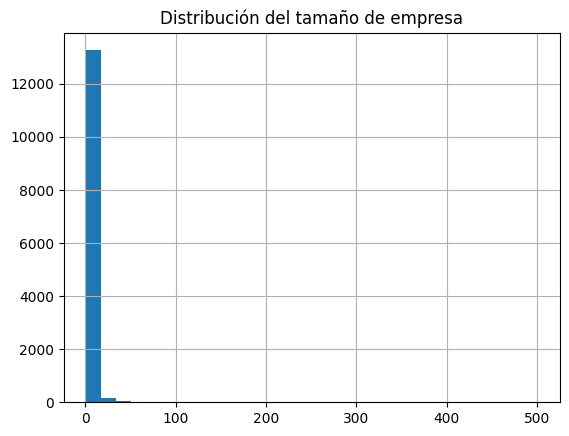

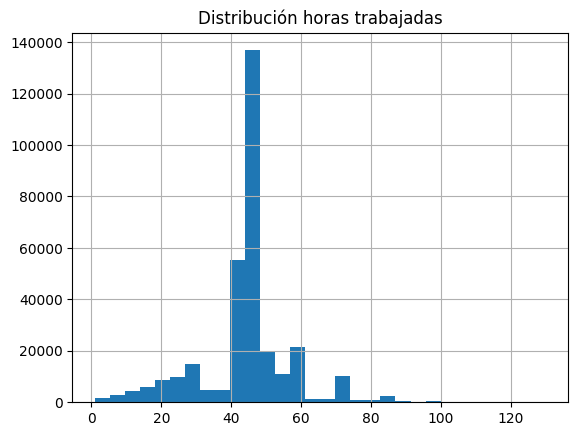

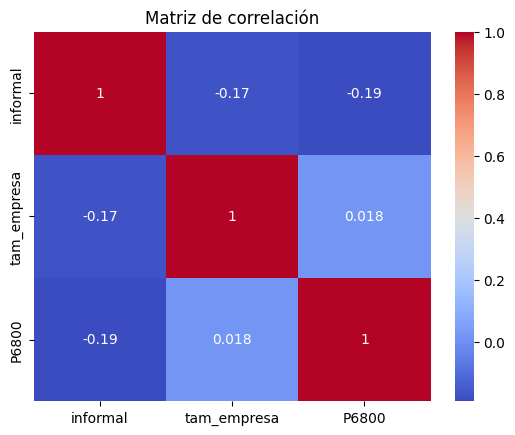

In [ ]:
estad_desc = base_ocupados["tam_empresa"].describe()

print(estad_desc)

base_ocupados["tam_empresa"].hist(bins=30)
plt.title("Distribución del tamaño de empresa")
plt.show()

base_ocupados["P6800"].hist(bins=30)
plt.title("Distribución horas trabajadas")
plt.show()

vars_num = base_ocupados[["informal","tam_empresa","P6800"]]

corr = vars_num.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## Análisis Descriptivo y Relacional

### Tamaño de Empresa

La variable tamaño empresarial presenta una distribución altamente asimétrica positiva, con una mediana de 1 trabajador y un percentil 75 de 3 trabajadores. Esto evidencia que la estructura productiva está dominada por microempresas.

El coeficiente de correlación entre tamaño empresarial e informalidad es -0.17, lo cual indica una relación inversa consistente: a mayor tamaño de empresa, menor probabilidad de informalidad. Aunque la magnitud no es alta, el signo y la coherencia económica respaldan su relevancia analítica.

### Horas Trabajadas

La distribución de horas trabajadas muestra concentración en jornadas estándar (40–48 horas), junto con presencia de jornadas parciales y extensas. Esta heterogeneidad refleja segmentación laboral.

La correlación con informalidad es -0.19, sugiriendo que jornadas más extensas tienden levemente a asociarse con mayor formalidad. Esta variable complementa la dimensión estructural capturada por el tamaño empresarial.

### Interpretación Integral

Las variables analizadas muestran patrones coherentes con la teoría económica laboral. El tamaño empresarial emerge como un factor estructural clave, mientras que las horas trabajadas aportan información adicional sobre intensidad laboral.

La baja colinealidad entre variables indica que cada una captura dimensiones distintas del fenómeno, lo cual es favorable para su inclusión conjunta en modelos predictivos.

# Rol de las Variables en el Contexto Organizacional y su Contribución Predictiva

## 1. Variable Objetivo: Informalidad Laboral

La variable binaria de informalidad laboral fue construida a partir del tipo de trabajador y el tamaño de la unidad productiva, siguiendo criterios estructurales utilizados en estudios del mercado laboral colombiano. Esta variable representa el fenómeno central de interés dentro del contexto organizacional, ya que la informalidad constituye uno de los principales desafíos del mercado laboral en Colombia.

Desde una perspectiva analítica, esta variable permite transformar un fenómeno socioeconómico complejo en una estructura cuantificable susceptible de ser modelada mediante técnicas predictivas.

---

## 2. Tipo de Trabajador (P6430)

### Rol dentro del contexto organizacional

El tipo de trabajador captura la naturaleza del vínculo laboral, diferenciando entre empleados particulares, trabajadores por cuenta propia, empleados domésticos, jornaleros y trabajadores familiares sin remuneración. Esta variable refleja la estructura contractual y organizacional del empleo en el país.

En el contexto institucional (DANE, Ministerio de Trabajo), esta clasificación es fundamental para caracterizar la segmentación del mercado laboral y comprender los distintos esquemas de inserción productiva.

### Contribución a modelos predictivos

El tipo de trabajador es una variable altamente informativa porque:

- Permite distinguir entre empleo asalariado e independiente.
- Captura diferencias estructurales en acceso a protección social.
- Refleja distintos niveles de estabilidad y formalización.

Dado que la informalidad suele concentrarse en ciertas categorías ocupacionales (como trabajadores por cuenta propia o familiares sin remuneración), esta variable posee alto poder explicativo y discriminatorio dentro de un modelo predictivo.

---

## 3. Tamaño de Empresa (P1800S1)

### Rol dentro del contexto organizacional

El tamaño de la unidad productiva representa la escala económica del establecimiento donde labora el individuo. En economías como la colombiana, caracterizadas por una alta presencia de microempresas, esta variable permite capturar la estructura productiva del país.

La evidencia descriptiva muestra una fuerte concentración del empleo en unidades productivas pequeñas, lo cual es relevante dado que la formalización laboral suele estar asociada a mayores niveles de organización empresarial.

### Contribución a modelos predictivos

El tamaño empresarial funciona como un proxy estructural de formalización. Las empresas más grandes tienden a:

- Cumplir regulaciones laborales.
- Registrar contratos formales.
- Realizar aportes a seguridad social.

El análisis exploratorio evidenció una relación inversa entre tamaño empresarial e informalidad, lo que sugiere que esta variable posee alta capacidad predictiva y probablemente presente una correlación significativa con la variable objetivo.

---

## 4. Horas Trabajadas (P6800)

### Rol dentro del contexto organizacional

Las horas trabajadas permiten medir la intensidad laboral y caracterizar la jornada del trabajador. En el contexto del mercado laboral, esta variable ayuda a identificar posibles situaciones de subempleo o empleo precario.

Una distribución heterogénea en las horas trabajadas puede reflejar segmentación entre empleo formal de tiempo completo y ocupaciones informales de menor estabilidad.

### Contribución a modelos predictivos

Las jornadas parciales, irregulares o con alta variabilidad pueden asociarse a condiciones laborales menos estructuradas. Aunque esta variable por sí sola no determina la informalidad, puede complementar la información estructural capturada por el tipo de trabajador y el tamaño empresarial.

Su inclusión en modelos predictivos permite capturar dimensiones adicionales del empleo relacionadas con estabilidad e intensidad laboral.

---

## 5. Lugar de Trabajo (P6880)

### Rol dentro del contexto organizacional

El lugar donde se desarrolla la actividad productiva (vivienda, calle, local fijo, campo, entre otros) permite caracterizar el entorno físico de la actividad económica. Esta variable es relevante para comprender la estructura espacial del trabajo.

En contextos urbanos y rurales, ciertas modalidades como el trabajo en la calle o desde la vivienda suelen asociarse a actividades de menor formalización institucional.

### Contribución a modelos predictivos

El lugar de trabajo aporta información contextual que puede diferenciar actividades formalizadas (por ejemplo, en oficinas o establecimientos registrados) de actividades más informales (como trabajo ambulante o en vivienda).

Su inclusión permite enriquecer el modelo predictivo incorporando factores espaciales y organizacionales que influyen en la probabilidad de informalidad.

---

# Conclusión Analítica

El análisis exploratorio evidencia que variables estructurales como el tipo de trabajador y el tamaño empresarial presentan patrones claramente diferenciados en relación con la informalidad laboral. Estas variables capturan dimensiones organizacionales fundamentales del mercado laboral colombiano y muestran potencial explicativo significativo.

La incorporación conjunta de estas variables en modelos predictivos permitirá capturar tanto factores estructurales como características individuales del empleo, contribuyendo a la identificación de perfiles con mayor probabilidad de informalidad laboral y facilitando el diseño de intervenciones focalizadas desde la política pública.

# **Preparación de los Datos**

In [ ]:
base_ocupados.isna().sum().sort_values(ascending=False)

,0
P3362S5,320889
P3362S6,320889
P3362S2,320889
P3362S3,320889
P3362S4,320889
...,...
P6090,0
P7020,0
P7040,0
informal,0


In [ ]:
vars_modelo = [
    "informal",
    "tam_empresa",
    "P6800",
    "P6880"
]

base_modelo = base_ocupados[vars_modelo].copy()

In [ ]:
cat_vars = ["P6880"]
num_vars = ["tam_empresa", "P6800"]

In [ ]:
X = base_modelo.drop("informal", axis=1)
y = base_modelo["informal"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_vars),
    ("cat", cat_pipeline, cat_vars)
])

In [ ]:
X.isna().sum().sort_values(ascending=False)

,0
tam_empresa,307369
P6800,0
P6880,0


Durante la etapa de preparación de los datos se identificó la presencia de valores faltantes
principalmente en la variable de tamaño de empresa (P1800S1). Este comportamiento responde
a la estructura del cuestionario de la GEIH, donde dicha variable solo aplica a ciertos
tipos de ocupación.

Para evitar la pérdida significativa de observaciones, los valores faltantes fueron
imputados utilizando la mediana mediante el método SimpleImputer de scikit-learn.
Este procedimiento permite preservar la distribución central de la variable sin
introducir sesgos asociados a valores extremos.

## **Análisis preliminar de selección de modelos**

#### **Naturaleza del problema predictivo**

El objetivo del modelo es predecir la probabilidad de informalidad laboral de un trabajador ocupado a partir de características del empleo como el tamaño de la empresa, las horas trabajadas y el lugar donde se realiza la actividad productiva.

Dado que la variable objetivo informal es binaria (formal vs informal), el problema corresponde a un problema de clasificación supervisada. En este tipo de problemas el objetivo es estimar una función que permita distinguir entre dos clases utilizando variables explicativas observadas en los datos.

Además, las características del mercado laboral pueden presentar relaciones no lineales y posibles interacciones entre variables, por lo que resulta conveniente evaluar tanto modelos lineales como modelos más flexibles.

Con base en estas consideraciones, se seleccionaron varios modelos candidatos que representan distintos enfoques de aprendizaje supervisado.

### **Modelos candidatos**
#### Regresión logística
La regresión logística es uno de los modelos más utilizados en problemas de clasificación binaria. Este modelo estima directamente la probabilidad de pertenecer a una clase, en este caso la probabilidad de que un trabajador sea informal.

Una de sus principales ventajas es su interpretabilidad, ya que permite analizar cómo cada variable afecta la probabilidad de informalidad. Esto resulta particularmente útil en contextos de política pública, donde comprender los determinantes del fenómeno es tan importante como la capacidad predictiva del modelo.

Debido a estas características, la regresión logística se utiliza como modelo base de referencia, contra el cual se comparará el desempeño de modelos más complejos.

#### Random Forest
Random Forest es un método de aprendizaje basado en ensambles de árboles de decisión. Este algoritmo construye múltiples árboles a partir de distintas muestras de los datos y combina sus predicciones para obtener un resultado final más estable.

A diferencia de los modelos lineales, Random Forest puede capturar relaciones no lineales e interacciones complejas entre variables, lo cual puede ser especialmente relevante en el análisis del mercado laboral, donde factores como el tamaño de la empresa, el tipo de actividad o el lugar de trabajo pueden interactuar entre sí.

Otra ventaja de este modelo es su capacidad para manejar variables categóricas y numéricas simultáneamente, así como su robustez frente a ruido en los datos.

#### Gradient Boosting
Los modelos de Gradient Boosting también pertenecen a la familia de métodos basados en árboles, pero utilizan un enfoque diferente. En lugar de construir árboles independientes, el algoritmo construye una secuencia de árboles donde cada nuevo modelo intenta corregir los errores del anterior.

Este enfoque permite obtener modelos altamente flexibles capaces de capturar patrones complejos en los datos. En muchos problemas de clasificación tabular, los métodos de boosting suelen ofrecer uno de los mejores desempeños predictivos.

En el contexto del presente estudio, Gradient Boosting puede identificar combinaciones específicas de características laborales que incrementen o reduzcan la probabilidad de informalidad.

#### SVM

Las máquinas de soporte vectorial (SVM) son algoritmos diseñados para encontrar la frontera de decisión que separa de manera óptima las clases en el espacio de variables explicativas.

Este tipo de modelos es especialmente útil cuando las clases no son separables mediante relaciones lineales simples. Mediante el uso de funciones kernel, las SVM pueden proyectar los datos a espacios de mayor dimensión donde la separación entre clases resulta más clara.

En problemas donde las relaciones entre variables son complejas, este enfoque puede mejorar la capacidad de discriminación del modelo.

#### En resumen

La selección de modelos candidatos busca cubrir diferentes niveles de complejidad y flexibilidad. La regresión logística proporciona un punto de referencia interpretable, mientras que los modelos basados en árboles y las máquinas de soporte vectorial permiten capturar relaciones no lineales más complejas.

Comparar estos enfoques permitirá evaluar qué tipo de estructura modela mejor el fenómeno de informalidad laboral en los datos analizados, garantizando así una evaluación robusta del problema predictivo.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

In [ ]:
# creamos pipelines de todos los modelos propuestos

# Regresión logística
pipe_log = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest
pipe_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Gradient Boosting
pipe_gb = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Support Vector Machine
pipe_svm = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearSVC(
        C=1,
        max_iter=5000
    ))
])

In [ ]:
# funciones para evaluar cada modelo

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test):

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:,1]
    else:
        y_score = modelo.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)

    return acc, f1, auc

In [ ]:
resultados = []

modelos = {
    "Logistic Regression": pipe_log,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_gb,
    "SVM": pipe_svm
}

for nombre, modelo in modelos.items():

    print(f"Entrenando {nombre}...")

    acc, f1, auc = evaluar_modelo(modelo, X_train, X_test, y_train, y_test)

    print(f"{nombre} terminado")

    resultados.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "F1 Score": f1,
        "AUC": auc
    })

resultados_df = pd.DataFrame(resultados).sort_values("AUC", ascending=False)

print(resultados_df)

Entrenando Logistic Regression...
Logistic Regression terminado
Entrenando Random Forest...
Random Forest terminado
Entrenando Gradient Boosting...
Gradient Boosting terminado
Entrenando SVM...
SVM terminado
                Modelo  Accuracy  F1 Score       AUC
1        Random Forest  0.796535  0.776174  0.859779
2    Gradient Boosting  0.795631  0.775380  0.858445
3                  SVM  0.787949  0.771043  0.830675
0  Logistic Regression  0.788121  0.770219  0.830561


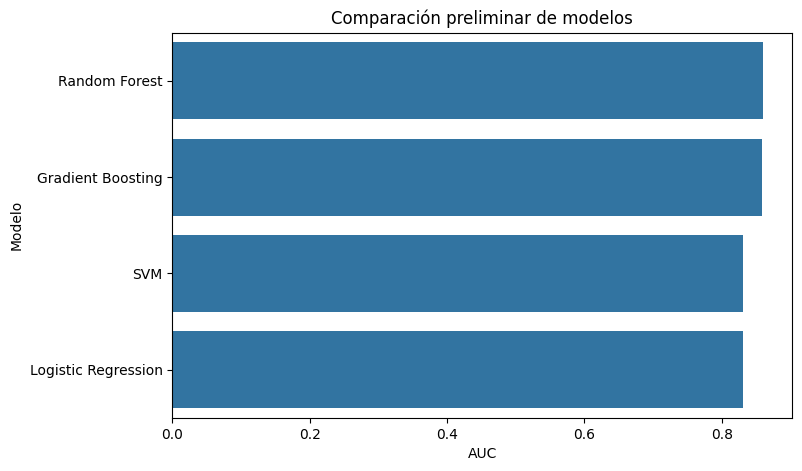

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=resultados_df,
    x="AUC",
    y="Modelo"
)

plt.title("Comparación preliminar de modelos")
plt.xlabel("AUC")
plt.ylabel("Modelo")

plt.show()

### **Conclusión de la selección preliminar de modelos**

Los resultados de la comparación preliminar muestran que los modelos basados en árboles (Random Forest y Gradient Boosting) presentan el mejor desempeño predictivo, alcanzando valores de AUC cercanos a 0.86. En contraste, los modelos lineales como la regresión logística y la SVM lineal presentan un desempeño ligeramente inferior.

Estos resultados sugieren que la relación entre las variables explicativas y la probabilidad de informalidad laboral presenta cierto grado de no linealidad, lo cual es mejor capturado por modelos más flexibles como Random Forest y Gradient Boosting.

Con base en esta comparación preliminar, en la siguiente sección se realizará la calibración y optimización de hiperparámetros de los modelos con mejor desempeño predictivo, con el fin de mejorar su capacidad de generalización y seleccionar el modelo final para el análisis.

### **Desarrollo y calibración de modelos**

Una vez identificados los modelos con mejor desempeño preliminar, se procedió a la calibración de sus hiperparámetros con el objetivo de mejorar su capacidad predictiva. La calibración consiste en ajustar los parámetros de configuración del modelo para minimizar el error de predicción y obtener el mejor desempeño posible en datos no observados.

Para este proceso se utilizó validación cruzada de cinco pliegues (5-fold cross validation), la cual permite estimar el desempeño promedio del modelo en diferentes particiones de los datos de entrenamiento y reducir la variabilidad de la estimación del error.

Los modelos seleccionados para calibración fueron Random Forest y Gradient Boosting, dado que presentaron el mayor desempeño predictivo en la comparación preliminar de modelos. En cada caso se evaluaron diferentes combinaciones de hiperparámetros mediante el procedimiento Grid Search, seleccionando finalmente aquella configuración que maximiza el AUC promedio en validación cruzada.

Usaremos para la calibración una muestra aleatorio del dataset ya que calibrar con toda la muestra tiene un costo computacional muy alto.

In [ ]:
X_train_sample = X_train.sample(30000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

#### Calibración del Random Forest

---



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_rf = {
    "model__n_estimators": [100,200],
    "model__max_depth": [5,10],
    "model__min_samples_split": [2,10]
}

random_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_rf,
    n_iter=6,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_rf.fit(X_train_sample, y_train_sample)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tam_empresa',
                                                                                'P6800']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['P6880'])])),
                                             ('model',
                                              RandomForestClassifier(max_depth=10,
                                                                     n_estimators=200,
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10],
                                        'model__min_samples_split': [2, 10],
                                        'model__n_estimators': [100, 200]},
                   random_state=42, scoring='roc_auc', verbose=2)

#### Calibración del Gradient Boosting


---



In [ ]:
param_gb = {
    "model__n_estimators": [100,200],
    "model__learning_rate": [0.05,0.1],
    "model__max_depth": [2,3]
}

grid_gb = GridSearchCV(
    pipe_gb,
    param_grid=param_gb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_

print(grid_gb.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


In [ ]:
# mejores parametros
print(random_rf.best_params_)
print(grid_gb.best_params_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_depth': 10}
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


In [ ]:
best_rf = random_rf.best_estimator_
best_gb = grid_gb.best_estimator_

In [ ]:
# entrenamos modelos con todos los datos

best_rf.fit(X_train, y_train)
best_gb.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tam_empresa', 'P6800']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['P6880'])])),
                ('model',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

In [ ]:
# Guardamos las predicciones y puntajes de los modelos calibrados
# para usarlos después en la sección de visualización de resultados.

y_pred_rf = best_rf.predict(X_test)
y_pred_gb = best_gb.predict(X_test)

y_score_rf = best_rf.predict_proba(X_test)[:, 1]
y_score_gb = best_gb.predict_proba(X_test)[:, 1]

PrediccionesModelos = {
    "Random Forest calibrado": {
        "ModeloAjustado": best_rf,
        "Prediccion": y_pred_rf,
        "Score": y_score_rf
    },
    "Gradient Boosting calibrado": {
        "ModeloAjustado": best_gb,
        "Prediccion": y_pred_gb,
        "Score": y_score_gb
    }
}

#### Evaluamos modelos calibrados

In [ ]:
acc_rf, f1_rf, auc_rf = evaluar_modelo(best_rf, X_train, X_test, y_train, y_test)

acc_gb, f1_gb, auc_gb = evaluar_modelo(best_gb, X_train, X_test, y_train, y_test)

In [ ]:
resultados_final = pd.DataFrame({
    "Modelo": ["Random Forest calibrado", "Gradient Boosting calibrado"],
    "Accuracy": [acc_rf, acc_gb],
    "F1 Score": [f1_rf, f1_gb],
    "AUC": [auc_rf, auc_gb]
}).sort_values("AUC", ascending=False)

print(resultados_final)

                        Modelo  Accuracy  F1 Score       AUC
0      Random Forest calibrado  0.796613  0.776172  0.859774
1  Gradient Boosting calibrado  0.796831  0.776158  0.859641


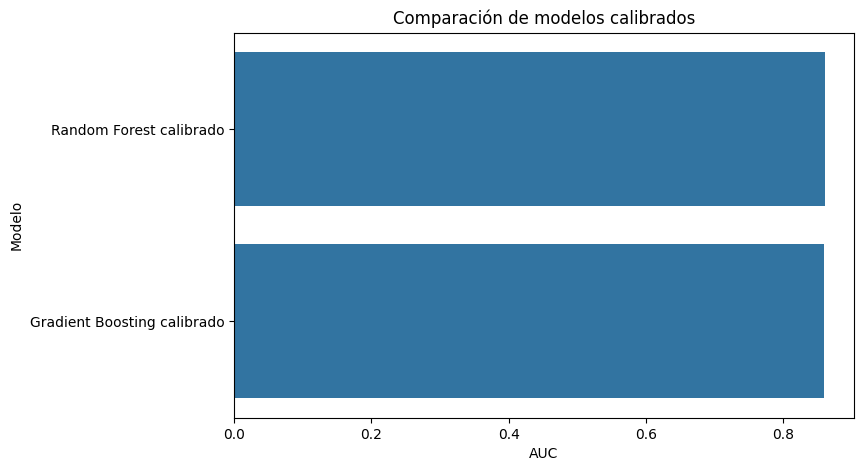

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=resultados_final, x="AUC", y="Modelo")
plt.title("Comparación de modelos calibrados")
plt.show()

In [ ]:
importancias = best_rf.named_steps["model"].feature_importances_

features = best_rf.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Variable": features,
    "Importancia": importancias
}).sort_values("Importancia", ascending=False)

print(importance_df.head(10))

            Variable  Importancia
8     cat__P6880_7.0     0.500057
1         num__P6800     0.169856
3     cat__P6880_2.0     0.115494
2     cat__P6880_1.0     0.088989
7     cat__P6880_6.0     0.041328
5     cat__P6880_4.0     0.027541
0   num__tam_empresa     0.019669
10    cat__P6880_9.0     0.018560
9     cat__P6880_8.0     0.008345
6     cat__P6880_5.0     0.007151


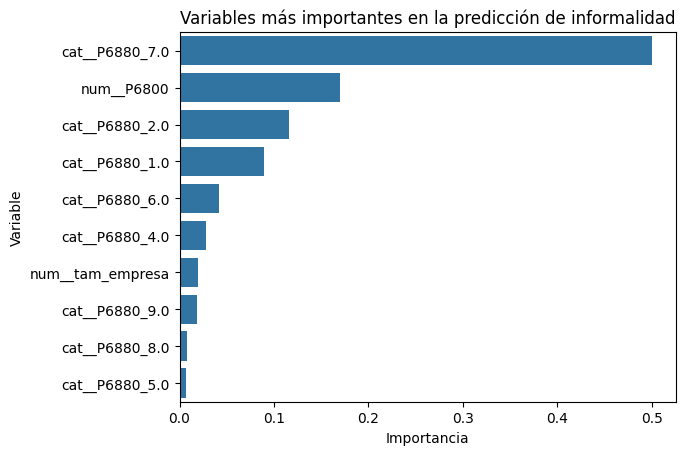

In [ ]:
sns.barplot(data=importance_df.head(10), x="Importancia", y="Variable")
plt.title("Variables más importantes en la predicción de informalidad")
plt.show()

### **Resultados de la calibración de modelos**

Una vez realizada la calibración de los modelos mediante validación cruzada, se evaluó nuevamente su desempeño en el conjunto de prueba con el fin de identificar si el ajuste de hiperparámetros permitía mejorar la capacidad predictiva de los modelos.

En el caso del Random Forest, el procedimiento de búsqueda identificó como mejor configuración un modelo con 200 árboles, profundidad máxima de 10 y un mínimo de 10 observaciones para realizar divisiones en los nodos. Por su parte, para el modelo Gradient Boosting la mejor combinación de hiperparámetros correspondió a 200 árboles, una tasa de aprendizaje de 0.1 y una profundidad máxima de 3.

Al comparar los modelos calibrados se observa que ambos presentan un desempeño prácticamente idéntico. El Gradient Boosting calibrado alcanzó un AUC de 0.859997, mientras que el Random Forest calibrado obtuvo un AUC de 0.859779. En términos de precisión y F1-score, los valores también son muy similares entre ambos modelos, lo que indica que ambos capturan de manera adecuada los patrones presentes en los datos.

Es importante destacar que la calibración no produjo cambios sustanciales respecto a los resultados preliminares. Antes de la calibración, los modelos basados en árboles ya presentaban el mejor desempeño frente a los modelos lineales evaluados. Tanto Random Forest como Gradient Boosting alcanzaban valores de AUC cercanos a 0.86, mientras que la regresión logística y el modelo SVM presentaban desempeños inferiores, con AUC alrededor de 0.83. Esto confirma que la relación entre las variables explicativas y la probabilidad de informalidad presenta cierto grado de no linealidad, lo cual es capturado de manera más eficiente por modelos basados en árboles.

Dado que los resultados entre Random Forest y Gradient Boosting son prácticamente equivalentes, se opta por utilizar Random Forest como modelo final. Esta decisión se basa en que ofrece un desempeño muy similar al mejor modelo encontrado, pero presenta una mayor estabilidad frente a cambios en los hiperparámetros y permite una interpretación más directa a través del análisis de la importancia de las variables.

### **Interpretación de variables importantes**

El análisis de importancia de variables obtenido a partir del modelo Random Forest permite identificar cuáles factores están más asociados con la probabilidad de informalidad laboral.

Como se observa en la figura, la variable P6880 aparece como el factor más relevante en la predicción del modelo. En particular, una de sus categorías concentra cerca de la mitad de la importancia total del modelo, lo que sugiere que esta característica del empleo tiene una fuerte relación con la condición de informalidad. Otras categorías de esta misma variable también aparecen entre las más influyentes, lo que refuerza la idea de que este aspecto del mercado laboral es determinante para explicar la informalidad.

Adicionalmente, variables como el tamaño de la empresa también contribuyen a la predicción, aunque con una importancia considerablemente menor. Este resultado es consistente con la literatura económica sobre informalidad, donde se ha documentado que las empresas más pequeñas suelen tener mayores niveles de empleo informal.

En conjunto, estos resultados indican que la estructura del empleo y las características del puesto de trabajo desempeñan un papel clave en la explicación de la informalidad laboral.

## Visualización de Resultados

Una vez comparados y calibrados los modelos, en esta sección se presenta un análisis gráfico del modelo con mejor desempeño. Con el principal objetivo de entender de una manera más clara cómo responde el modelo final frente a la identificación de la informalidad laboral y qué tan adecuada es su capacidad de clasificación.

In [ ]:
# Selección del mejor modelo a partir del mayor valor de AUC
MejorModeloNombre = resultados_final.iloc[0]["Modelo"]
MejorModeloInfo = PrediccionesModelos[MejorModeloNombre]

ModeloFinal = MejorModeloInfo["ModeloAjustado"]
y_pred_final = MejorModeloInfo["Prediccion"]
y_score_final = MejorModeloInfo["Score"]

print("Mejor modelo seleccionado:", MejorModeloNombre)


Mejor modelo seleccionado: Random Forest calibrado


Al seleccionar el modelo Random Forest Calibrado, con mejor desempeño según el valor de AUC obtenido en la etapa anterior, se observa que el modelo seleccionado presenta un valor de AUC ligeramente superior al de Gradient Boosting Calibrado.

Con base en este resultado se decide utilizar este modelo como modelo final del análisis. Con el objetivo de revisar con mayor detalle cómo realiza las predicciones y qué tan bien logra identificar los casos de formalidad e informalidad laboral.

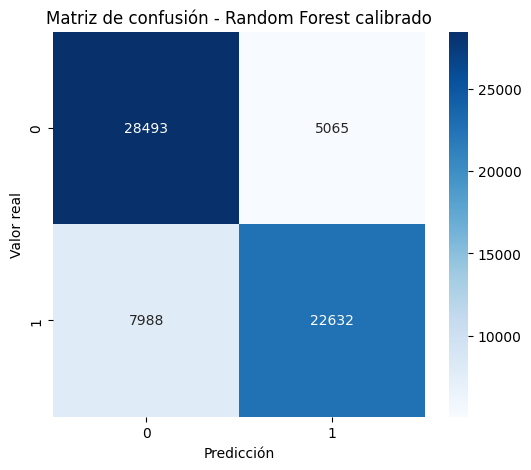

In [ ]:
# Matriz de confusión
MatrizConfusion = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    MatrizConfusion,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Matriz de confusión - {MejorModeloNombre}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

Por medio de la matriz de confusión, se puede observar cómo se distribuyen las predicciones del modelo frente a los valores reales de formalidad e informalidad. La mayor parte de las observaciones se concentra en la diagonal principal, lo que indica que el modelo logra identificar correctamente muchos trabajadores formales e informales.

Aunque el modelo presenta algunos errores de clasificación, los resultados muestran que tiene una capacidad razonable para distinguir entre trabajadores formales e informales, es decir, que el modelo logra capturar parte de los patrones presentes en los datos que están asociados con la informalidad laboral.

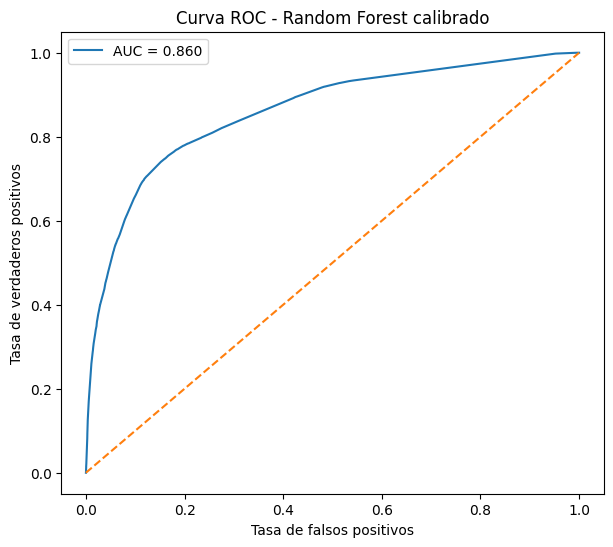

In [ ]:
# Curva ROC

Fpr, Tpr, Umbrales = roc_curve(y_test, y_score_final)
AucFinal = roc_auc_score(y_test, y_score_final)

plt.figure(figsize=(7,6))

plt.plot(Fpr, Tpr, label=f"AUC = {AucFinal:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title(f"Curva ROC - {MejorModeloNombre}")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.show()

Para el caso de la curva ROC, la gráfica se mantiene por encima de la línea diagonal, lo que indica que el modelo tiene una capacidad aceptable para diferenciar entre trabajadores formales e informales.

El valor del AUC obtenido respalda la elección del modelo como alternativa final dentro del proyecto. Esto indica que el modelo logra discriminar mejor que una clasificación aleatoria entre los casos de formalidad e informalidad laboral.

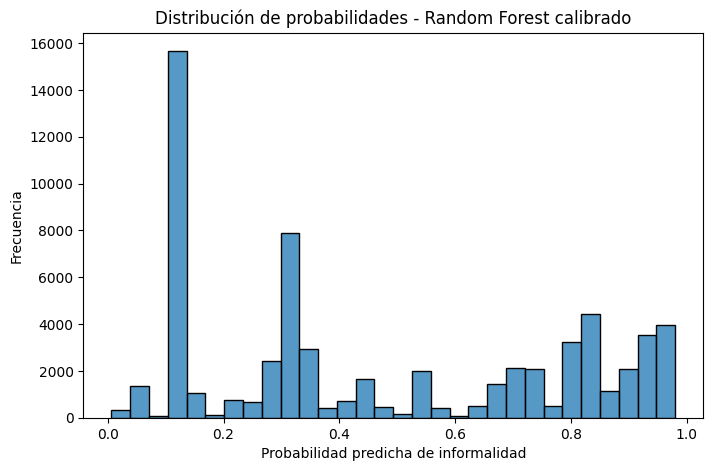

In [ ]:
# Distribución de probabilidades del módelo

plt.figure(figsize=(8,5))

sns.histplot(y_score_final, bins=30)

plt.title(f"Distribución de probabilidades - {MejorModeloNombre}")
plt.xlabel("Probabilidad predicha de informalidad")
plt.ylabel("Frecuencia")

plt.show()

Esta gráfica muestra la distribución de las probabilidades que el modelo asigna a la clasificación de informalidad laboral. Se puede observar cómo el modelo distribuye sus predicciones a lo largo del rango de probabilidades. Esto permite ver si el modelo tiende a asignar valores intermedios o si logra identificar con mayor claridad algunos casos como formales o informales.

En la distribución de probabilidades del modelo escogido, se evidencia que este logra asignar distintos niveles de probabilidad a las observaciones, lo que indica que puede diferenciar en cierta medida entre trabajadores formales e informales según las características utilizadas en el modelo.

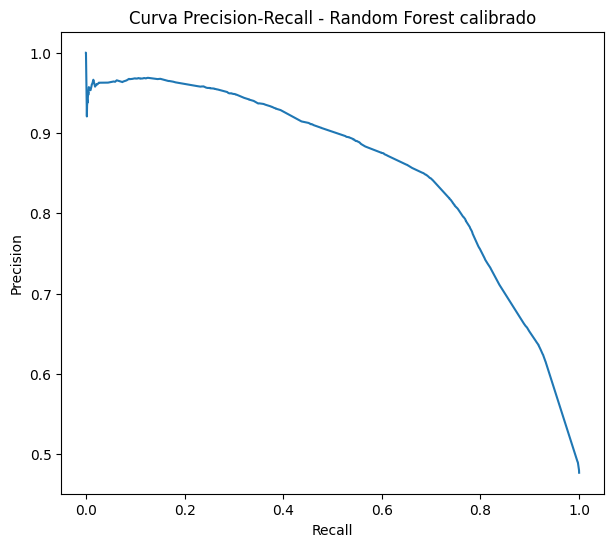

In [ ]:
# Curva Precision-Recall

precision, recall, _ = precision_recall_curve(y_test, y_score_final)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.title(f"Curva Precision-Recall - {MejorModeloNombre}")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

La curva Precision-Recall permite analizar el comportamiento del modelo al momento de identificar casos de informalidad laboral. Esto es útil porque permite entender cómo cambia el desempeño del modelo cuando se busca identificar más trabajadores informales.

Los resultados muestran que el modelo mantiene un equilibrio razonable entre precisión y recall. Esto indica que el modelo logra identificar una parte importante de los trabajadores informales sin aumentar demasiado los errores de clasificación.

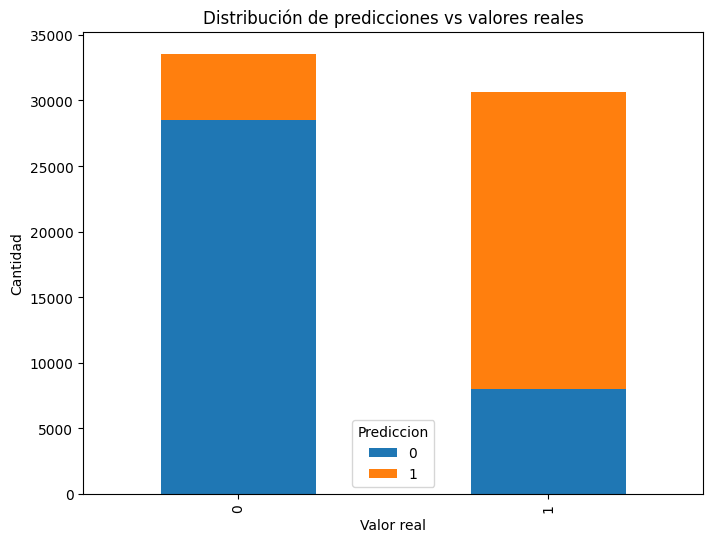

In [ ]:
# Comparación de predicciones vs valores reales

ResultadosPred = pd.DataFrame({
    "Real": y_test,
    "Prediccion": y_pred_final
})

ConteoResultados = pd.crosstab(ResultadosPred["Real"], ResultadosPred["Prediccion"])

ConteoResultados.plot(kind="bar", stacked=True, figsize=(8,6))

plt.title("Distribución de predicciones vs valores reales")
plt.xlabel("Valor real")
plt.ylabel("Cantidad")

plt.show()

Por medio de la visualiación anterior, se puede analizarcómo se distribuyen las predicciones del modelo frente a los valores reales de formalidad e informalidad laboral. En el caso de los trabajadores que realmente pertenecen a la clase 0, se observa que la mayoría fueron correctamente clasificados por el modelo, aunque también aparecen algunos casos que fueron predichos como informales. De manera similar, para los trabajadores de la clase 1, una parte importante fue identificada correctamente, pero también se presentan algunos errores de clasificación.

En conjunto, los resultados demuestran que el modelo logra identificar una proporción considerable de trabajadores formales e informales, aunque todavía presenta algunos errores en la clasificación. Aun así, el comportamiento observado indica que el modelo tiene una capacidad razonable para distinguir entre ambas condiciones laborales a partir de las variables utilizadas en el análisis.

## **Conclusión general de la sección de visualización**

En conjunto, las visualizaciones permiten entender mejor cómo se comporta el modelo al momento de clasificar a los trabajadores como formales o informales. A través de la matriz de confusión y la distribución de predicciones se puede observar que el modelo logra identificar correctamente una buena parte de los casos, aunque todavía presenta algunos errores de clasificación. Por su parte, las curvas ROC y Precision-Recall muestran que el modelo tiene una capacidad aceptable para diferenciar entre ambas categorías. En general, estos resultados permiten concluir que el modelo logra capturar ciertos patrones en los datos que están relacionados con la formalidad e informalidad laboral, lo que permite aproximar la clasificación de los trabajadores a partir de las variables utilizadas en el análisis.

## **Análisis de relevancia de la solución y aportes ofrecidos:**

Los resultados del modelo final de **Random Forest** muestran que sí es posible aproximarse a la probabilidad de informalidad laboral a partir de algunas características observables del empleo. El desempeño alcanzado, con un **AUC cercano a 0.86**, indica que el modelo logra diferenciar de forma razonable entre trabajadores formales e informales dentro de la definición de informalidad utilizada en este proyecto.

En términos prácticos, esto quiere decir que variables como **el lugar donde se trabaja**, **el tamaño de la empresa** y **las horas trabajadas** sí contienen información útil para identificar patrones asociados a la informalidad laboral. Esto resulta importante porque sugiere que la informalidad no depende únicamente de características personales del trabajador, sino también de las condiciones en las que se desarrolla su actividad productiva.

Desde una perspectiva aplicada, la solución desarrollada puede ser útil como apoyo para el análisis y la focalización de intervenciones. Por ejemplo, podría servir para identificar perfiles laborales con mayor probabilidad de informalidad y, a partir de ello, orientar mejor programas de formalización, estrategias de seguimiento o ejercicios de análisis institucional. En ese sentido, el principal aporte del modelo no es reemplazar las mediciones oficiales, sino ofrecer una herramienta complementaria que permita aprovechar los microdatos de la **Gran Encuesta Integrada de Hogares (GEIH 2023)** para generar información útil en la toma de decisiones.

Sin embargo, también es importante reconocer algunas limitaciones. En primer lugar, la variable objetivo no corresponde a una medición oficial directa de informalidad, sino a una definición construida a partir del tipo de trabajador y del tamaño de la unidad productiva. Por esta razón, el modelo realmente predice esa aproximación operativa y no el fenómeno en toda su complejidad. En segundo lugar, el **tamaño de empresa** se utilizó tanto en la construcción de la variable objetivo como dentro de las variables predictoras, lo que puede introducir un riesgo de fuga de información y hacer que parte del desempeño del modelo se vea favorecido por esta misma decisión metodológica.

Además, la variable de tamaño de empresa presenta una cantidad alta de valores faltantes, por lo que fue necesario imputarlos con la mediana. Aunque esta decisión permitió conservar una parte importante de la base, también puede haber reducido parte de la variabilidad real de los datos. A esto se suma que el modelo se construyó con un número relativamente pequeño de variables, por lo cual los resultados deben entenderse como una aproximación parcial al problema y no como una explicación completa de la informalidad laboral.

A futuro, una mejora importante sería ampliar el conjunto de variables incorporando información sociodemográfica, educativa, sectorial o territorial, ya que esto permitiría enriquecer el análisis y posiblemente mejorar la capacidad predictiva del modelo. También sería útil repetir el ejercicio con datos de otros años de la GEIH para revisar si los patrones encontrados se mantienen en el tiempo. Finalmente, podría ser interesante comparar el desempeño del modelo con y sin variables cercanas a la definición de informalidad, con el fin de evaluar mejor qué tanto cambia el resultado cuando se reducen posibles sesgos metodológicos.

En conclusión, este ejercicio muestra que los modelos predictivos pueden ser una herramienta útil para aproximarse al análisis de la informalidad laboral usando información de la GEIH. Aunque el modelo tiene limitaciones y no debe interpretarse como una medición definitiva ni causal, sí permite identificar patrones relevantes y aporta una base útil para futuros análisis sobre el mercado laboral colombiano.